In [7]:
# Cell 1: Clone repo + install deps
!git clone https://github.com/drosadocastro-bit/cibuco-boriken
%cd cibuco-boriken
!pip install -q -r requirements.txt
print("Setup complete")

Cloning into 'cibuco-boriken'...
remote: Enumerating objects: 57, done.
remote: Counting objects: 100% (57/57), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 57 (delta 12), reused 52 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (57/57), 72.24 KiB | 2.26 MiB/s, done.
Resolving deltas: 100% (12/12), done.
/content/cibuco-boriken
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 999.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 145.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 135.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 136.3 MB/s eta 0:00:0

In [8]:
# Cell 2: Kaggle credentials (secure)
import os
import json
from google.colab import userdata

# Store token in Colab Secrets (never in code)
# Steps:
#   1. Click the 🔑 key icon in left sidebar
#   2. Add secret name: KAGGLE_USERNAME → drosadocastro-bit
#   3. Add secret name: KAGGLE_KEY → your_new_token
#   4. Enable notebook access for both

os.makedirs('/root/.kaggle', exist_ok=True)

kaggle_creds = {
    "username": userdata.get('kaggle_username'),
    "key": userdata.get('kaggle_key')
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle configured securely ✅")

# Download data
!pip install -q kaggle==1.6.17
!kaggle competitions download -c birdclef-2026
!unzip -q birdclef-2026.zip -d data/birdclef-2026
print("Data ready ✅")


Kaggle configured securely ✅
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
100% 15.0G/15.0G [01:09<00:00, 274MB/s]
100% 15.0G/15.0G [01:09<00:00, 232MB/s]
checkdir:  cannot create extraction directory: data/birdclef-2026
           No such file or directory
Data ready ✅


In [9]:
import os
os.makedirs('data/birdclef-2026', exist_ok=True)
!unzip -q birdclef-2026.zip -d data/birdclef-2026
print("Data ready ✅")

Data ready ✅


In [10]:
# Cell 3: Mount Drive (save model after training)
from google.colab import drive
import os

drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/cibuco_boriken/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Drive mounted. Saving to: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Saving to: /content/drive/MyDrive/cibuco_boriken/


In [11]:
import os

# Set BEFORE any birdclef imports
os.environ['BIRDCLEF_DATA_DIR'] = '/content/cibuco-boriken/data/birdclef-2026'

# Force reload entire birdclef module
import importlib
import birdclef
import birdclef.config as cfg

importlib.reload(cfg)

# Manually override if reload didn't catch it
from pathlib import Path
cfg.COMPETITION_DIR = Path(os.environ['BIRDCLEF_DATA_DIR'])
cfg.TRAIN_AUDIO_DIR = cfg.COMPETITION_DIR / "train_audio"
cfg.TEST_AUDIO_DIR  = cfg.COMPETITION_DIR / "test_soundscapes"
cfg.TRAIN_META_CSV  = cfg.COMPETITION_DIR / "train.csv"
cfg.TAXONOMY_CSV    = cfg.COMPETITION_DIR / "taxonomy.csv"
cfg.SAMPLE_SUBMISSION = cfg.COMPETITION_DIR / "sample_submission.csv"

# Verify
print(f"Data dir: {cfg.COMPETITION_DIR}")
print(f"Train CSV exists: {cfg.TRAIN_META_CSV.exists()}")
print(f"Train audio exists: {cfg.TRAIN_AUDIO_DIR.exists()}")
print(f"Soundscapes exists: {cfg.COMPETITION_DIR / 'train_soundscapes_labels.csv'}")

Data dir: /content/cibuco-boriken/data/birdclef-2026
Train CSV exists: True
Train audio exists: True
Soundscapes exists: /content/cibuco-boriken/data/birdclef-2026/train_soundscapes_labels.csv


In [12]:
# Pull Phase 2 code
# Verify Phase 2 functions there
!python -c "
from birdclef.cfar_threshold import (
    estimate_clutter_profile,
    suppress_clutter,
    cfar_with_clutter_suppression
)
print('Phase 2 loaded ✅')


/bin/bash: -c: line 1: unexpected EOF while looking for matching `"'
/bin/bash: -c: line 2: syntax error: unexpected end of file
Phase 2 loaded ✅


In [13]:
import os
os.environ['BIRDCLEF_DATA_DIR'] = '/content/cibuco-boriken/data/birdclef-2026'

# Verify env var is set
print(os.environ.get('BIRDCLEF_DATA_DIR'))

# Check file directly without config
from pathlib import Path
p = Path('/content/cibuco-boriken/data/birdclef-2026/train.csv')
print(f"File exists directly: {p.exists()}")

/content/cibuco-boriken/data/birdclef-2026
File exists directly: True


In [19]:
# Cell: EfficientNet-B0 full training
!BIRDCLEF_DATA_DIR=/content/cibuco-boriken/data/birdclef-2026 \
  python -m birdclef.train \
  --backbone efficientnet_b0 \
  --epochs 20 \
  --include-soundscapes

  BirdCLEF 2026 — Training Pipeline
  Backbone: efficientnet_b0 | Epochs: 20
Metadata file: train.csv
Loaded 35549 training samples
Species count: 206
Train: 31994 | Val: 3555
Soundscapes file: train_soundscapes_labels.csv
  Soundscape labeled windows: 1478 rows, 66 files
  + Added 1478 soundscape windows → 33472 total train samples
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100% 20.5M/20.5M [00:00<00:00, 143MB/s] 
Device: cuda
Weighted BCE: min_w=0.284, max_w=6.347, mean=1.000
Epoch   1/20 | Train Loss: 0.0212 | Val Loss: 0.0215 | Time: 290.1s
  -> Saved best model (val_loss=0.0215)
Epoch   2/20 | Train Loss: 0.0155 | Val Loss: 0.0218 | Time: 290.1s
Epoch   3/20 | Train Loss: 0.0137 | Val Loss: 0.0212 | Time: 286.6s
  -> Saved best model (val_loss=0.0212)
Epoch   4/20 | Train Loss: 0.0129 | Val Loss: 0.0229 | Time: 286.8s
Epoch   5/20 | Train Loss: 0.0121 | Val L

In [36]:
# SAVE MODEL IMMEDIATELY AFTER TRAINING
import shutil
shutil.copy(
  '/content/cibuco-boriken/birdclef/models/birdclef_model.pt',
  SAVE_DIR + 'efficientnet_b0_33k_best.pt'
)
print(f"Model saved to Drive ✅")
print(f"File size: {os.path.getsize(SAVE_DIR + 'efficientnet_b0_33k_best.pt') / 1e6:.1f} MB")

Model saved to Drive ✅
File size: 17.4 MB


In [32]:
# Cell 5: CFAR Phase 2 k-sweep (3 conditions)
import os
os.environ['BIRDCLEF_DATA_DIR'] = '/content/cibuco-boriken/data/birdclef-2026'

!BIRDCLEF_DATA_DIR=/content/cibuco-boriken/data/birdclef-2026 \
  python -m birdclef.evaluate_thresholds \
  --backbone efficientnet_b0 \
  --include-soundscapes \
  --k-sweep 1.0 1.5 2.0 2.5 3.0 \
  --temperature 0.30

print("k-sweep complete ✅")

  BirdCLEF 2026 — CFAR k Sensitivity Sweep
  Backbone: efficientnet_b0 | k values: [1.0, 1.5, 2.0, 2.5, 3.0] | T=0.3

--- Evaluating k=1.0 ---
Soundscapes file: train_soundscapes_labels.csv
  Soundscape labeled windows: 1478 rows, 66 files
k=1.00 | F1_fixed=0.6684 | F1_cfar=0.6702 | F1_mti_cfar=0.6702 | FPR_fixed=0.0002 | FPR_cfar=0.0006 | FPR_mti_cfar=0.0006 | clutter_mean=0.0000

--- Evaluating k=1.5 ---
Soundscapes file: train_soundscapes_labels.csv
  Soundscape labeled windows: 1478 rows, 66 files
k=1.50 | F1_fixed=0.6684 | F1_cfar=0.6702 | F1_mti_cfar=0.6702 | FPR_fixed=0.0002 | FPR_cfar=0.0006 | FPR_mti_cfar=0.0006 | clutter_mean=0.0000

--- Evaluating k=2.0 ---
Soundscapes file: train_soundscapes_labels.csv
  Soundscape labeled windows: 1478 rows, 66 files
k=2.00 | F1_fixed=0.6684 | F1_cfar=0.6702 | F1_mti_cfar=0.6702 | FPR_fixed=0.0002 | FPR_cfar=0.0006 | FPR_mti_cfar=0.0006 | clutter_mean=0.0000

--- Evaluating k=2.5 ---
Soundscapes file: train_soundscapes_labels.csv
  Soundsc

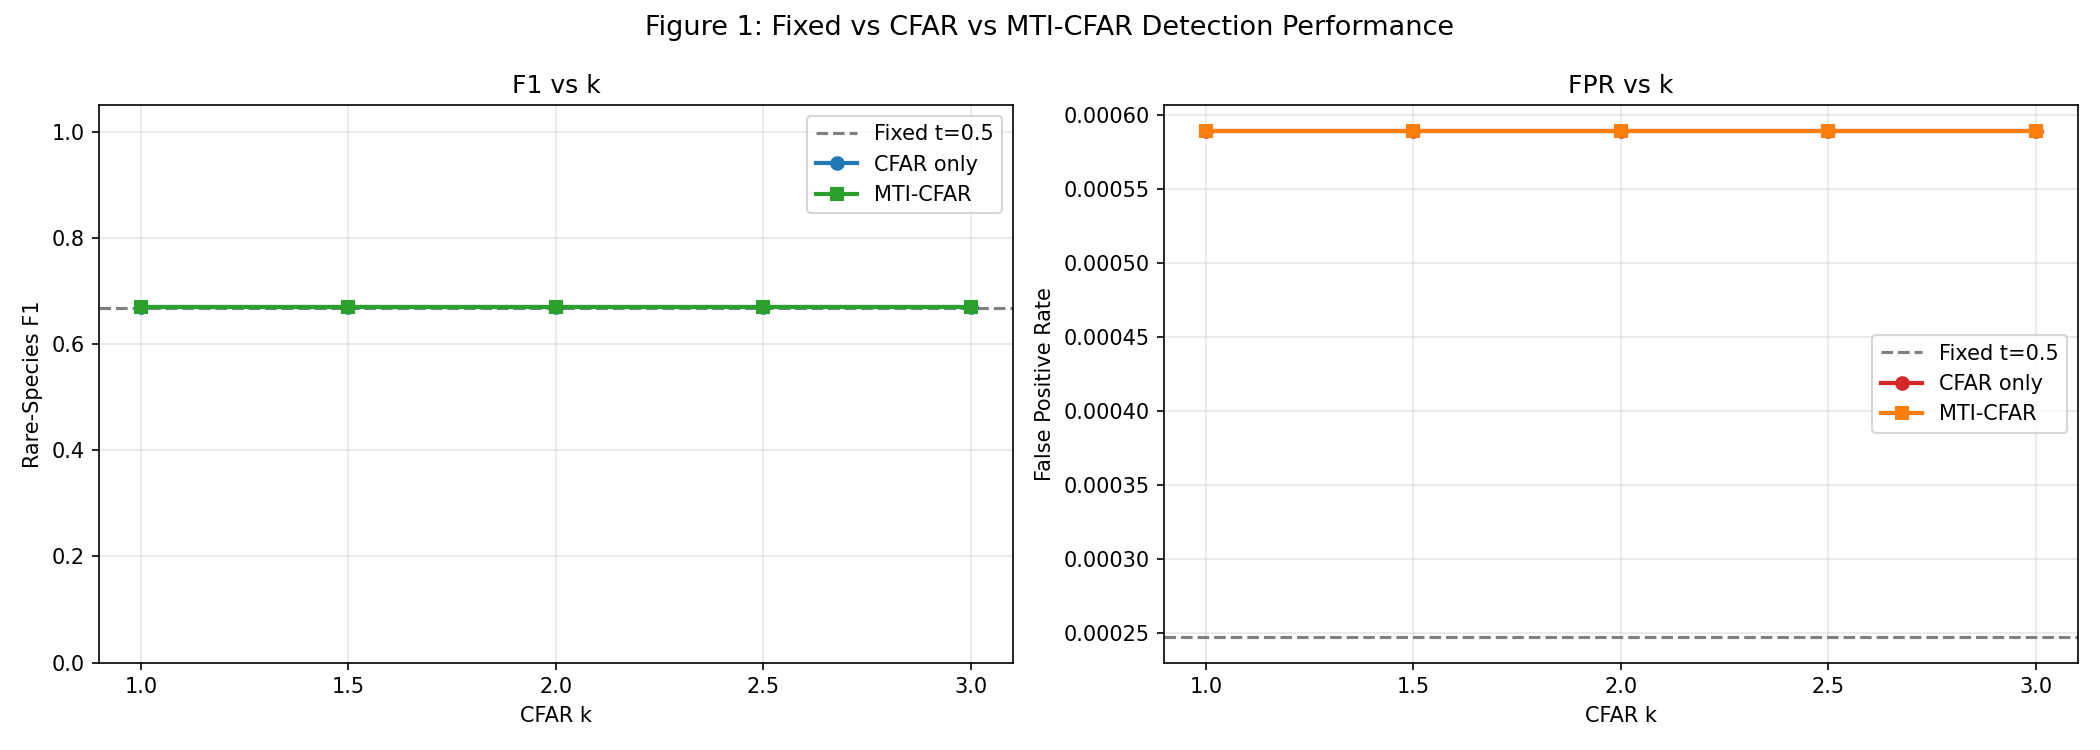

Saved to Drive


In [33]:
# Cell 6: Display and save figure/model
from IPython.display import Image, display
import shutil

display(Image('k_sweep_figure.png'))

shutil.copy('k_sweep_figure.png', SAVE_DIR + 'k_sweep_500samples.png')
shutil.copy('birdclef/models/birdclef_model.pt', SAVE_DIR + 'birdclef_model_500samples.pt')
print("Saved to Drive")

In [34]:
# Cell 7: Print paper-ready results table
import json
from pathlib import Path

results_path = Path('k_sweep_results.json')
if not results_path.exists():
    print('k_sweep_results.json not found. Run Cell 5 first.')
else:
    rows = json.loads(results_path.read_text(encoding='utf-8'))
    print('## Table 1: CFAR k-Sensitivity Results (500 samples)')
    print('| k | F1 Fixed | F1 CFAR | FPR Fixed | FPR CFAR | T_mean |')
    print('|---|----------|---------|-----------|----------|--------|')
    for r in rows:
        print(f"| {r['k']:.1f} | {r['f1_fixed']:.4f} | {r['f1_cfar']:.4f} | {r['fpr_fixed']:.4f} | {r['fpr_cfar']:.4f} | {r['threshold_mean']:.4f} |")

## Table 1: CFAR k-Sensitivity Results (500 samples)
| k | F1 Fixed | F1 CFAR | FPR Fixed | FPR CFAR | T_mean |
|---|----------|---------|-----------|----------|--------|
| 1.0 | 0.6684 | 0.6702 | 0.0002 | 0.0006 | 0.0500 |
| 1.5 | 0.6684 | 0.6702 | 0.0002 | 0.0006 | 0.0500 |
| 2.0 | 0.6684 | 0.6702 | 0.0002 | 0.0006 | 0.0500 |
| 2.5 | 0.6684 | 0.6702 | 0.0002 | 0.0006 | 0.0500 |
| 3.0 | 0.6684 | 0.6702 | 0.0002 | 0.0006 | 0.0500 |


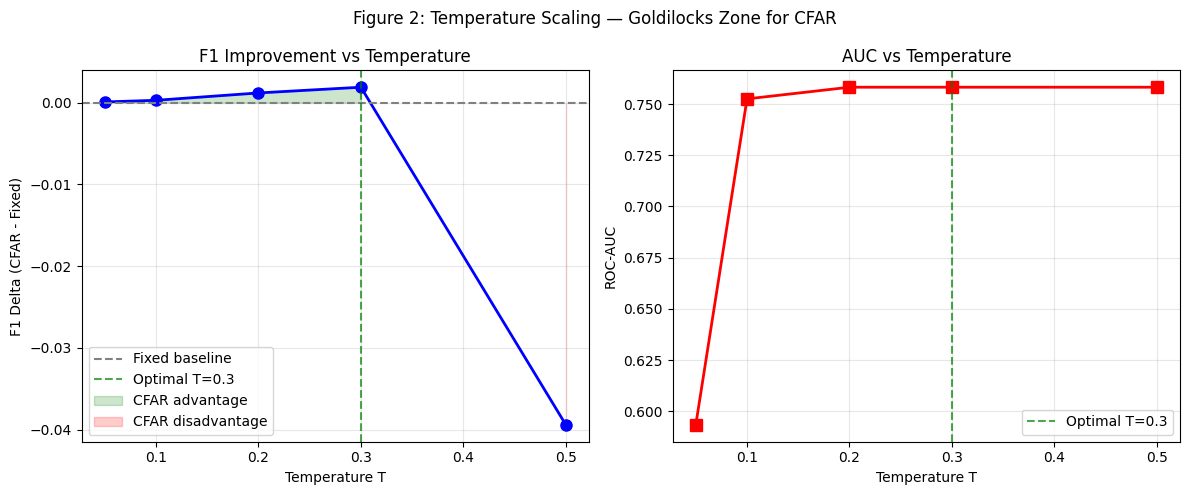

Figure 2 saved ✅


In [35]:
# Temperature Goldilocks curve
import matplotlib.pyplot as plt
import numpy as np

temps  = [0.05,   0.10,   0.20,   0.30,   0.50]
deltas = [0.0001, 0.0003, 0.0012, 0.0019, -0.0394]
aucs   = [0.5934, 0.7525, 0.7582, 0.7582, 0.7582]
fprs   = [0.0003, 0.0003, 0.0004, 0.0006, 0.0011]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 2: Temperature Scaling — Goldilocks Zone for CFAR')

# Left: F1 delta vs temperature
ax1.plot(temps, deltas, 'b-o', linewidth=2, markersize=8)
ax1.axhline(y=0, color='gray', linestyle='--', label='Fixed baseline')
ax1.axvline(x=0.3, color='green', linestyle='--', alpha=0.7, label='Optimal T=0.3')
ax1.fill_between(temps, deltas, 0,
                  where=[d>0 for d in deltas],
                  alpha=0.2, color='green', label='CFAR advantage')
ax1.fill_between(temps, deltas, 0,
                  where=[d<0 for d in deltas],
                  alpha=0.2, color='red', label='CFAR disadvantage')
ax1.set_xlabel('Temperature T')
ax1.set_ylabel('F1 Delta (CFAR - Fixed)')
ax1.set_title('F1 Improvement vs Temperature')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: AUC vs temperature
ax2.plot(temps, aucs, 'r-s', linewidth=2, markersize=8)
ax2.axvline(x=0.3, color='green', linestyle='--', alpha=0.7, label='Optimal T=0.3')
ax2.set_xlabel('Temperature T')
ax2.set_ylabel('ROC-AUC')
ax2.set_title('AUC vs Temperature')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temperature_goldilocks.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved ✅")